# Mean-variance optimisation: lookback window sensitivity

Markowitz's recipe is simple: estimate each asset's expected return and the covariance
between them, then pick the mix with the best return per unit of risk. Every mix that
can't be beaten on both counts at once lies on the efficient frontier; the
maximum-Sharpe portfolio is the point on it with the steepest line from zero.

The catch is that nobody knows the expected returns, so they are estimated from a
trailing window of prices, and the optimiser treats that estimate as true. It hunts for
the assets whose past returns look best relative to their risk, which are usually the
ones whose estimates are most wrong. This is why the method is called an "error
maximiser": a few days more or less of history can move the whole portfolio from one
asset to another.

The price data covers 2023 to 2025, so the windows compared here are 30 days, 90 days
and one year, not multi-year. The assets are five large coins with a price on every
day: bitcoin, ether, solana, XRP and chainlink. The notebook draws the frontier, shows how it and
its chosen weights move from day to day under each window, and measures how far a
change of a few days in the window moves the weights. It then backtests the portfolios
against equal weight with monthly rebalancing and fees, checks other settings and other
baskets, and renders a video.

In [1]:
import itertools
from functools import cache

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from algo_trading.backtest import backtest as bt, data, plots
from algo_trading.backtest.config import FEE_BPS, PROJECT_ROOT, PortfolioConfig

plots.apply_theme()

# 15-minute bars, 2023-2025, resampled to daily on load.
DATA = PROJECT_ROOT / ".data" / "ohlcv_15m.csv"
TOKENS = ["btc", "eth", "sol", "xrp", "link"]
NAMES = {"btc": "BTC", "eth": "ETH", "sol": "SOL", "xrp": "XRP", "link": "LINK"}

LOOKBACKS = {"30-day": 30, "90-day": 90, "1-year": 365}   # days of returns per estimate
MONTH = 30                     # rebalance every 30 days
WARMUP = max(LOOKBACKS.values()) + 1   # every window starts trading on the same day
FEE = FEE_BPS                  # 0.2% per fill
INITIAL = 10_000
ASSET_COLORS = [plots.color(i) for i in range(len(TOKENS))]   # one per asset
LB_COLORS = plots.ramp(len(LOOKBACKS))                       # short -> long window
EW_COLOR = plt.rcParams["axes.labelcolor"]                   # the benchmark, in grey
MV_COLOR = plots.ramp(3, hue="purple")[-1]
# Weight maps: zero recedes into the surface, a full position stands out.
WEIGHT_CMAP = plots.BLUES.reversed() if plots.is_dark() else plots.BLUES

## Data

In [2]:
raw = data.load_bars("1d", TOKENS, path=DATA, fmt="ohlcv")
panel = data.daily_panel(TOKENS, raw=raw)
close = panel.close[TOKENS].dropna()            # start once every coin has a price
rets = close.pct_change().iloc[1:]
ANN = panel.bars_per_year
print(panel.describe())
print(f"{close.index[0]:%Y-%m-%d} -> {close.index[-1]:%Y-%m-%d}, "
      f"trading from {close.index[WARMUP]:%Y-%m-%d}")

1,096 1d bars x 5 tokens  2023-01-01 00:00:00+00:00 -> 2025-12-31 00:00:00+00:00
2023-01-01 -> 2025-12-31, trading from 2024-01-02


## How much each asset moves

,total_ret,mean_ret,vol,sharpe,max_dd
BTC,+427%,+66%,47%,1.42,-32%
ETH,+147%,+50%,63%,0.79,-64%
SOL,+1144%,+124%,90%,1.37,-60%
XRP,+443%,+91%,87%,1.04,-49%
LINK,+117%,+62%,86%,0.72,-63%


correlation of daily returns


,BTC,ETH,SOL,XRP,LINK
BTC,1.00,0.79,0.71,0.52,0.65
ETH,0.79,1.00,0.69,0.55,0.73
SOL,0.71,0.69,1.00,0.51,0.64
XRP,0.52,0.55,0.51,1.00,0.57
LINK,0.65,0.73,0.64,0.57,1.00


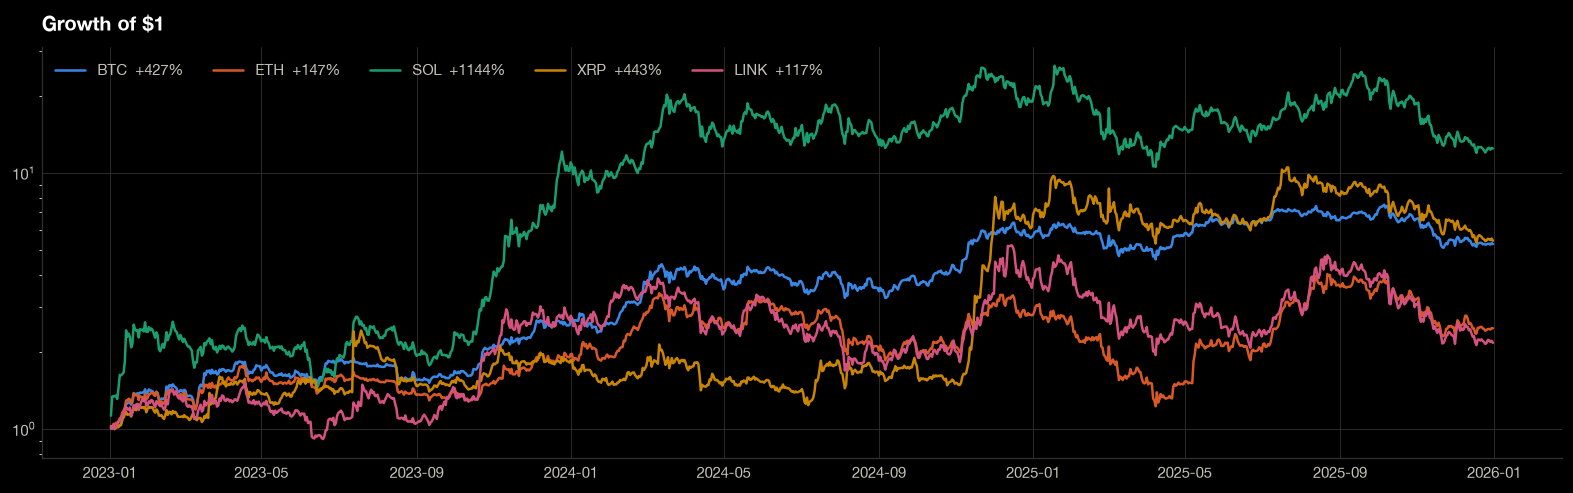

In [3]:
growth = (1 + rets).cumprod()
summary = pd.DataFrame({"total_ret": growth.iloc[-1] - 1,
                        "mean_ret": rets.mean() * ANN,
                        "vol": rets.std() * np.sqrt(ANN),
                        "sharpe": rets.mean() / rets.std() * np.sqrt(ANN),
                        "max_dd": (growth / growth.cummax() - 1).min()}).rename(index=NAMES)
display(bt.fmt_table(summary, {"total_ret": "{:+.0%}", "mean_ret": "{:+.0%}", "vol": "{:.0%}",
                               "sharpe": "{:.2f}", "max_dd": "{:.0%}"}))
print("correlation of daily returns")
display(rets.rename(columns=NAMES).corr().round(2))

fig, ax = plt.subplots(figsize=(13, 4), layout="constrained")
for t, col in zip(TOKENS, ASSET_COLORS):
    ax.plot(growth[t], color=col, lw=1.5, label=f"{NAMES[t]}  {growth[t].iloc[-1] - 1:+.0%}")
ax.set_yscale("log")
ax.set_title("Growth of $1")
ax.legend(loc="upper left", ncol=5)
plt.show()

## The optimiser

Everything below is long-only and fully invested: weights are between 0 and 1 and sum
to 1. Inputs are the annualised mean and covariance of daily returns over the window.

* **Maximum Sharpe** (the tangency portfolio) maximises $\mu^\top w / \sqrt{w^\top \Sigma w}$,
  with a risk-free rate of zero. It needs the expected returns $\mu$.
* **Minimum variance** minimises $w^\top \Sigma w$ and ignores $\mu$ altogether. It is
  the leftmost point of the frontier, and a useful control: whatever instability it
  shows comes from the covariance alone.

With five assets there is no need for a numerical solver. The optimum holds some subset
of the assets, and on that subset the answer has a closed form, so trying all 31
subsets and keeping the best one with no negative weight gives the exact solution.

In [4]:
@cache
def supports(n: int) -> list[np.ndarray]:
    """Every non-empty subset of n assets: the candidate sets of holdings."""
    return [np.array(s) for k in range(1, n + 1) for s in itertools.combinations(range(n), k)]


def _solve(cov: np.ndarray, S: np.ndarray, b: np.ndarray) -> np.ndarray | None:
    """Solve cov[S, S] x = b, or None if that block is singular."""
    try:
        return np.linalg.solve(cov[np.ix_(S, S)], b)
    except np.linalg.LinAlgError:
        return None


def min_variance(cov: np.ndarray) -> np.ndarray:
    """Long-only, fully invested minimum-variance weights.

    On its holdings S the answer is w_S ∝ cov_S^-1 1, so solve on every subset, keep
    those with all weights positive, and take the one with the least variance."""
    n = len(cov)
    best, best_var = None, np.inf
    for S in supports(n):
        v = _solve(cov, S, np.ones(len(S)))
        if v is None or (v <= 0).any():
            continue
        w = np.zeros(n)
        w[S] = v / v.sum()
        if (var := w @ cov @ w) < best_var:
            best, best_var = w, var
    return best


def max_sharpe(mu: np.ndarray, cov: np.ndarray) -> np.ndarray:
    """Long-only, fully invested maximum-Sharpe weights (risk-free rate 0).

    On its holdings S the answer is w_S ∝ cov_S^-1 mu_S. If no mix has a positive
    expected return in the window there is no positive Sharpe to find, and it holds the
    minimum-variance mix instead."""
    n = len(mu)
    best, best_sr = None, 0.0
    for S in supports(n):
        v = _solve(cov, S, mu[S])
        if v is None or (v <= 0).any():
            continue
        w = np.zeros(n)
        w[S] = v / v.sum()
        if (sr := mu @ w / np.sqrt(w @ cov @ w)) > best_sr:
            best, best_sr = w, sr
    return best if best is not None else min_variance(cov)


def frontier(mu: np.ndarray, cov: np.ndarray, n_points: int = 40) -> np.ndarray:
    """Long-only efficient frontier as (vol, return) rows, from minimum variance up to
    the best single asset.

    For a target return r, the least-variance fully invested mix on a subset S is
    w = cov_S^-1 (a 1 + b mu_S), with a and b set by the two constraints. Keep the
    lowest variance over subsets whose weights are all non-negative."""
    r = np.linspace(mu @ min_variance(cov), mu.max(), n_points)
    var = np.full(n_points, np.inf)
    for S in supports(len(mu)):
        if len(S) == 1:                        # a single asset sits at one return only
            hit = np.isclose(r, mu[S[0]])
            var[hit] = np.minimum(var[hit], cov[S[0], S[0]])
            continue
        ci1, cim = _solve(cov, S, np.ones(len(S))), _solve(cov, S, mu[S])
        if ci1 is None:
            continue
        A, B, C = ci1.sum(), cim.sum(), mu[S] @ cim
        D = A * C - B * B
        if D <= 1e-12 * A * C:                 # all means equal: no second direction
            continue
        a, b = (C - B * r) / D, (A * r - B) / D
        ok = ((np.outer(a, ci1) + np.outer(b, cim)) >= -1e-12).all(axis=1)
        v = (A * r * r - 2 * B * r + C) / D
        var = np.where(ok & (v < var), v, var)
    return np.column_stack([np.sqrt(var), r])


def estimates(px: pd.DataFrame, i: int, lookback: int) -> tuple[np.ndarray, np.ndarray]:
    """Annualised mean and covariance of the `lookback` daily returns up to close i."""
    win = px.to_numpy(float)[i - lookback:i + 1]
    r = win[1:] / win[:-1] - 1
    return r.mean(axis=0) * ANN, np.cov(r.T) * ANN


def rolling(px: pd.DataFrame, lookback: int, how: str = "max sharpe") -> pd.DataFrame:
    """Optimal weights from the trailing `lookback` days, bar by bar (NaN before)."""
    out = np.full(px.shape, np.nan)
    for i in range(lookback, len(px)):
        mu, cov = estimates(px, i, lookback)
        out[i] = max_sharpe(mu, cov) if how == "max sharpe" else min_variance(cov)
    return pd.DataFrame(out, index=px.index, columns=px.columns)

## The efficient frontier

First with the whole period's returns, which is hindsight: the best any single estimate
could have done. Each dot is one asset; the curve is the best volatility available at
each expected return using any long-only mix.

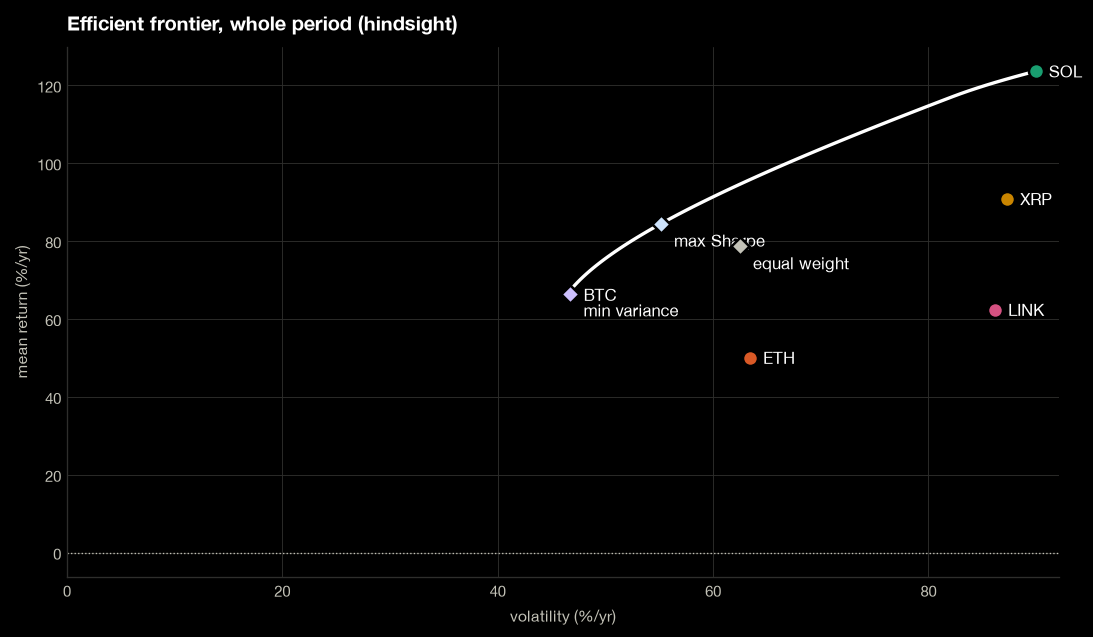

,BTC,ETH,SOL,XRP,LINK
max Sharpe,62%,0%,27%,12%,0%
min variance,99%,0%,0%,1%,0%
equal weight,20%,20%,20%,20%,20%


In [5]:
mu_full, cov_full = rets.mean().to_numpy() * ANN, rets.cov().to_numpy() * ANN
fr = frontier(mu_full, cov_full, 80)
picks = {"max Sharpe": max_sharpe(mu_full, cov_full),
         "min variance": min_variance(cov_full),
         "equal weight": np.full(len(TOKENS), 1 / len(TOKENS))}


def point(w: np.ndarray, mu: np.ndarray, cov: np.ndarray) -> tuple[float, float]:
    return np.sqrt(w @ cov @ w), mu @ w


fig, ax = plt.subplots(figsize=(9, 5.2), layout="constrained")
ax.plot(fr[:, 0] * 100, fr[:, 1] * 100, color=plt.rcParams["text.color"], lw=2, zorder=2)
for j, t in enumerate(TOKENS):
    ax.plot(np.sqrt(cov_full[j, j]) * 100, mu_full[j] * 100, "o", ms=9, color=ASSET_COLORS[j],
            mec=plt.rcParams["axes.facecolor"], mew=1.5, zorder=4)
    ax.annotate(NAMES[t], (np.sqrt(cov_full[j, j]) * 100, mu_full[j] * 100), xytext=(8, 0),
                textcoords="offset points", va="center")
for (k, w), col in zip(picks.items(), (LB_COLORS[-1], MV_COLOR, EW_COLOR)):
    v, r = point(w, mu_full, cov_full)
    ax.plot(v * 100, r * 100, "D", ms=8, color=col, mec=plt.rcParams["axes.facecolor"], mew=1.5,
            zorder=5)
    ax.annotate(k, (v * 100, r * 100), xytext=(8, -10), textcoords="offset points", va="center")
ax.axhline(0, color=plt.rcParams["axes.labelcolor"], lw=0.8, ls=":")
ax.set_xlim(left=0)
ax.set_xlabel("volatility (%/yr)")
ax.set_ylabel("mean return (%/yr)")
ax.set_title("Efficient frontier, whole period (hindsight)")
plt.show()

bt.fmt_table(pd.DataFrame(picks, index=[NAMES[t] for t in TOKENS]).T,
             {NAMES[t]: "{:.0%}" for t in TOKENS})

## Same day, different windows

Now the frontier as an investor would have estimated it on three dates, from the
trailing 30 days, 90 days and year. The diamond is the maximum-Sharpe pick. Each panel
has its own scale: a 30-day window routinely implies returns of hundreds of percent a
year.

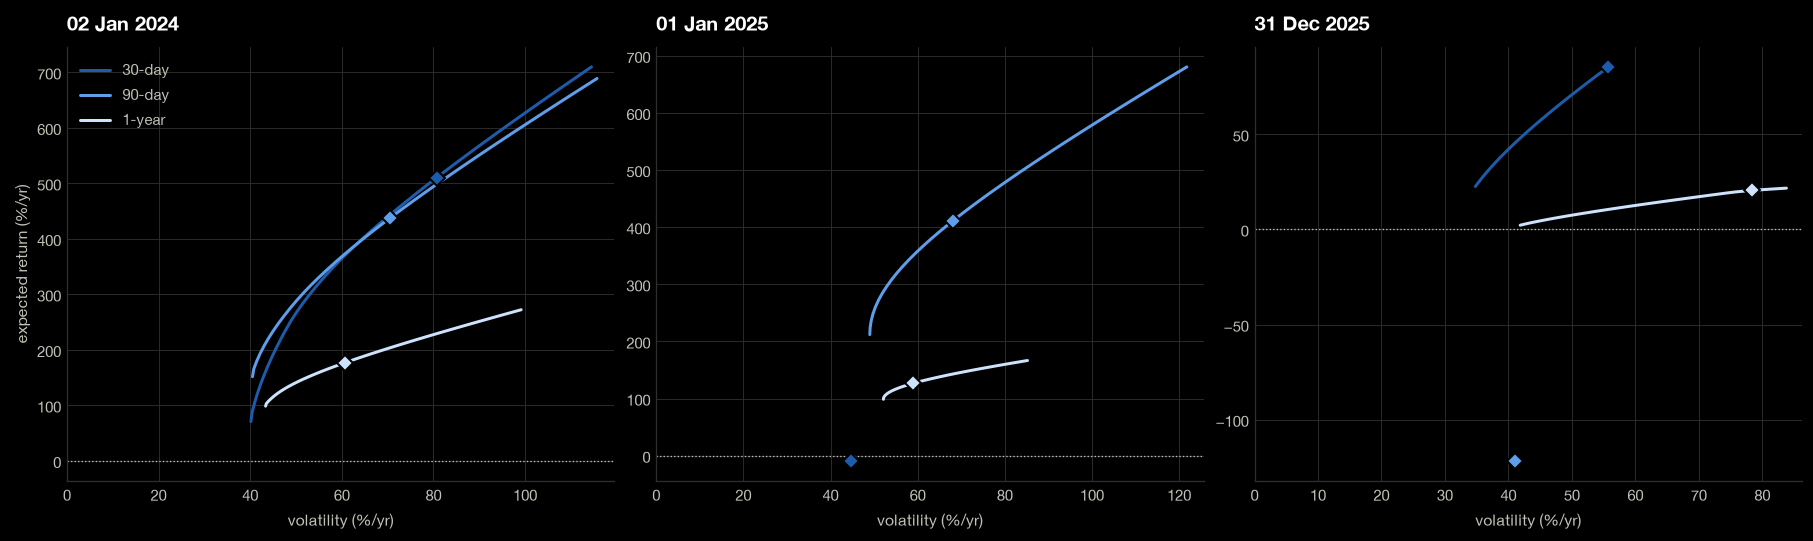

maximum-Sharpe weights


BTC   ETH  SOL  XRP LINK
02 Jan 2024 30-day   36%    0%  64%   0%   0%
            90-day   52%    0%  48%   0%   0%
            1-year   58%    0%  42%   0%   0%
01 Jan 2025 30-day  100%    0%   0%   0%   0%
            90-day   55%    0%   0%  45%   0%
            1-year   51%    0%   0%  49%   0%
31 Dec 2025 30-day    0%  100%   0%   0%   0%
            90-day  100%    0%   0%   0%   0%
            1-year    0%   22%   0%  78%   0%

In [6]:
span = close.index[WARMUP:]
dates = [span[0], span[len(span) // 2], span[-1]]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4), layout="constrained")
rows = {}
for ax, d in zip(axes, dates):
    i = close.index.get_loc(d)
    for (lab, lb), col in zip(LOOKBACKS.items(), LB_COLORS):
        mu, cov = estimates(close, i, lb)
        f = frontier(mu, cov)
        w = max_sharpe(mu, cov)
        v, r = point(w, mu, cov)
        ax.plot(f[:, 0] * 100, f[:, 1] * 100, color=col, lw=1.8, label=lab)
        ax.plot(v * 100, r * 100, "D", ms=7, color=col, mec=plt.rcParams["axes.facecolor"],
                mew=1.2, zorder=5)
        rows[(f"{d:%d %b %Y}", lab)] = dict(zip([NAMES[t] for t in TOKENS], w))
    ax.axhline(0, color=plt.rcParams["axes.labelcolor"], lw=0.8, ls=":")
    ax.set_xlim(left=0)
    ax.set_title(f"{d:%d %b %Y}")
    ax.set_xlabel("volatility (%/yr)")
axes[0].set_ylabel("expected return (%/yr)")
axes[0].legend(loc="upper left")
plt.show()

print("maximum-Sharpe weights")
bt.fmt_table(pd.DataFrame(rows).T, {NAMES[t]: "{:.0%}" for t in TOKENS})

## Weights through time

The target weights re-solved every day. Each strip is one window, one row per asset,
brighter for a larger weight. The left column is maximum Sharpe; the right is minimum
variance, which drops the expected returns.

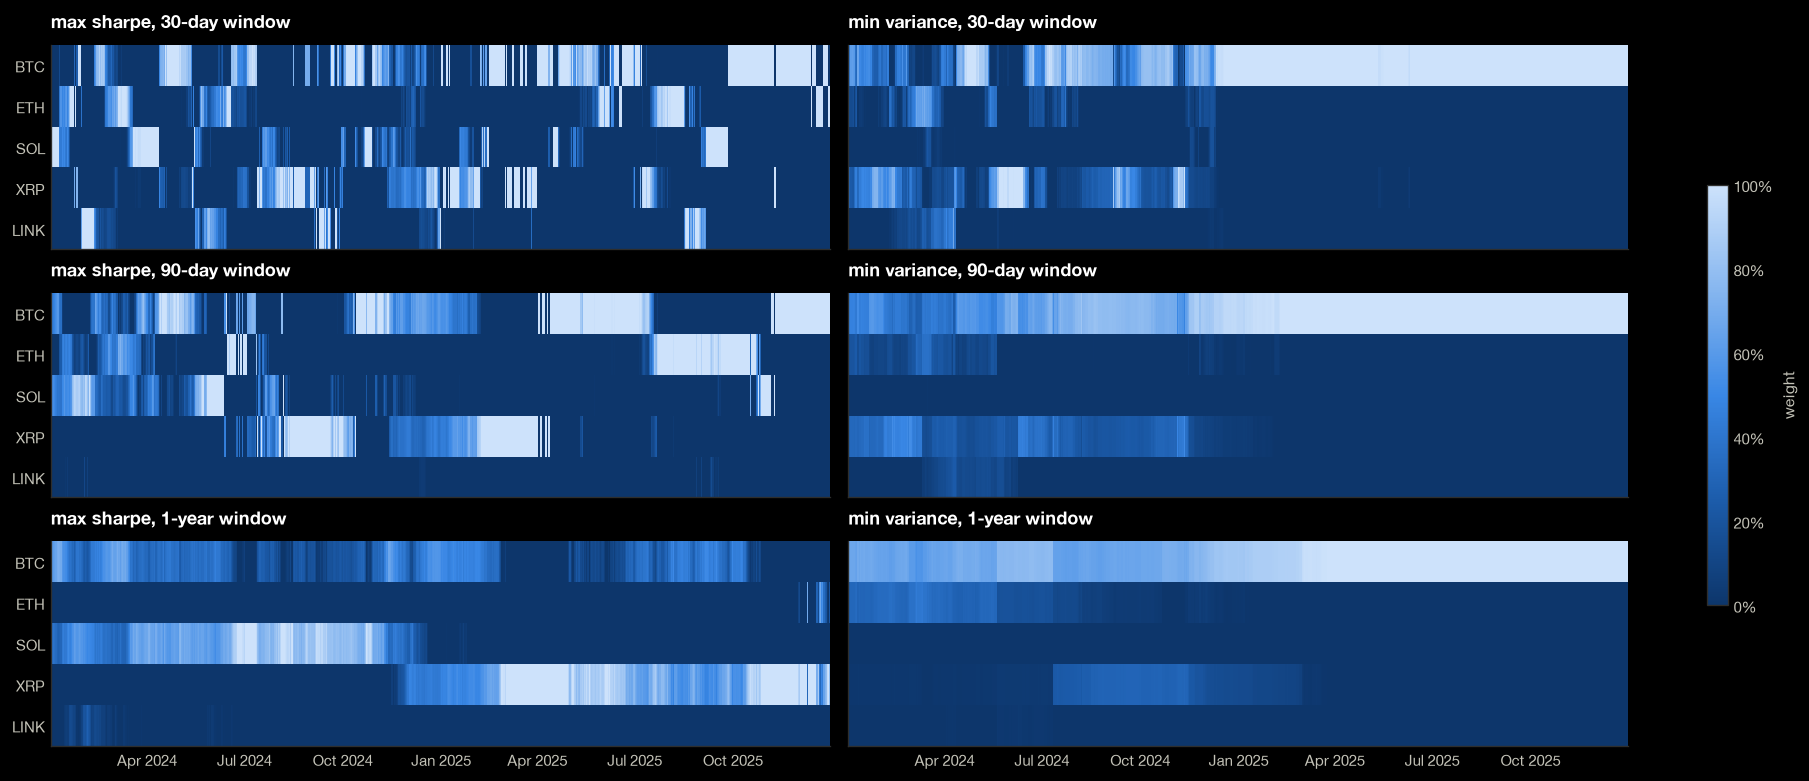

daily_change top_switches eff_n max_w  BTC  ETH  SOL  XRP  \
scheme       window                                                             
max sharpe   30-day        14.8%          115  1.37   86%  41%  15%  15%  20%   
             90-day         8.1%           60  1.38   85%  41%  20%  14%  25%   
             1-year         3.3%           31  1.64   74%  26%   1%  31%  41%   
min variance 30-day         3.3%           33  1.40   86%  77%   5%   0%  16%   
             90-day         1.1%            6  1.53   82%  82%   3%   0%  13%   
             1-year         0.4%            0  1.42   84%  84%   9%   0%   7%   

                    LINK  
scheme       window       
max sharpe   30-day   9%  
             90-day   0%  
             1-year   1%  
min variance 30-day   2%  
             90-day   2%  
             1-year   0%

In [7]:
HOW = ("max sharpe", "min variance")
targets = {(how, lab): rolling(close, lb, how) for how in HOW for lab, lb in LOOKBACKS.items()}

fig, axes = plt.subplots(len(LOOKBACKS), 2, figsize=(15, 6.4), layout="constrained",
                         sharex=True, sharey=True)
x0, x1 = mdates.date2num(span[0]), mdates.date2num(span[-1])
for c, how in enumerate(HOW):
    for r, lab in enumerate(LOOKBACKS):
        ax = axes[r, c]
        im = ax.imshow(targets[(how, lab)].loc[span].T.to_numpy(), cmap=WEIGHT_CMAP, vmin=0,
                       vmax=1, aspect="auto", interpolation="nearest",
                       extent=(x0, x1, len(TOKENS) - 0.5, -0.5))
        ax.set_yticks(range(len(TOKENS)), [NAMES[t] for t in TOKENS])
        ax.set_title(f"{how}, {lab} window", fontsize=10.5)
        ax.grid(False)
        ax.xaxis_date()
        ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=(1, 4, 7, 10)))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
fig.colorbar(im, ax=axes, shrink=0.6, label="weight", format=lambda v, _: f"{v:.0%}")
plt.show()


def churn(w: pd.DataFrame) -> dict:
    """How much a daily target moves: one-way change per day, top-holding switches,
    effective number of holdings (1 / sum w^2) and the largest weight, all averaged."""
    w = w.loc[span]
    top = w.idxmax(axis=1)
    return {"daily_change": (w.diff().abs().sum(axis=1) / 2).iloc[1:].mean(),
            "top_switches": int((top != top.shift()).iloc[1:].sum()),
            "eff_n": (1 / (w ** 2).sum(axis=1)).mean(),
            "max_w": w.max(axis=1).mean(),
            **{f"{NAMES[t]}": w[t].mean() for t in TOKENS}}


stability = pd.DataFrame({k: churn(w) for k, w in targets.items()}).T
stability.index.names = ["scheme", "window"]
bt.fmt_table(stability, {"daily_change": "{:.1%}", "top_switches": "{:.0f}", "eff_n": "{:.2f}",
                         "max_w": "{:.0%}", **{NAMES[t]: "{:.0%}" for t in TOKENS}})

`daily_change` is the share of the book the target moves each day (half the summed
absolute change in weights), `top_switches` how often the largest holding changed over
the period, `eff_n` the effective number of holdings ($1/\sum w^2$: 1 is a single asset,
5 is equal weight) and `max_w` the average largest weight. The asset columns are the
average weights.

## Small shifts, big swings

On the last day of the data, the maximum-Sharpe weights for windows a few days either
side of each of the three. Nothing about the assets changes between neighbouring rows;
only a few days of history are added or dropped.

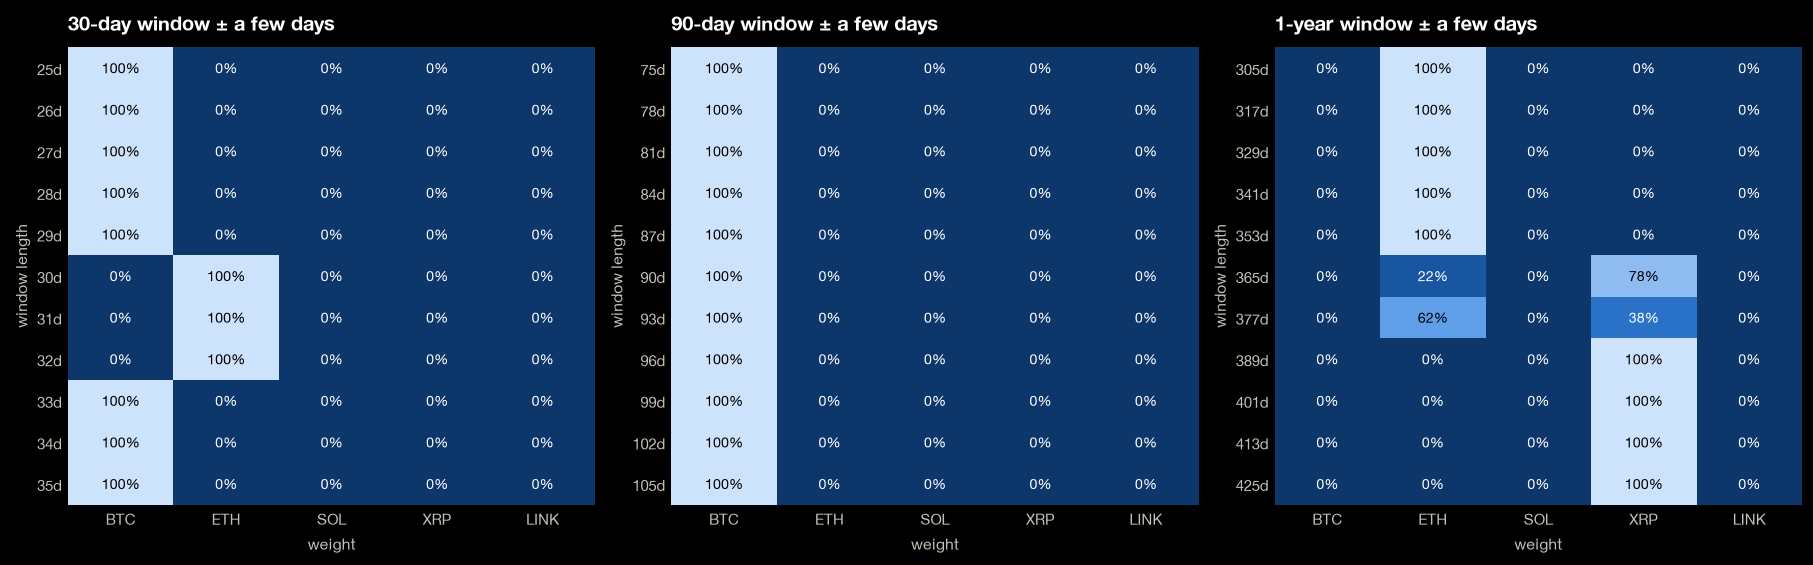

In [8]:
i_last = len(close) - 1
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), layout="constrained")
for ax, (lab, lb) in zip(axes, LOOKBACKS.items()):
    step = max(1, lb // 30)
    lbs = [lb + d * step for d in range(-5, 6)]
    shift = pd.DataFrame({n: max_sharpe(*estimates(close, i_last, n)) for n in lbs},
                         index=[NAMES[t] for t in TOKENS]).T
    shift.index = [f"{n}d" for n in lbs]
    plots.heatmap(shift, f"{lab} window ± a few days", fmt="{:.0%}", ax=ax,
                  cmap=WEIGHT_CMAP, xlabel="weight", ylabel="window length")
plt.show()

### Why the means are the problem

The standard error of an annualised mean return estimated from $T$ days is roughly the
asset's annual volatility divided by $\sqrt{T/365}$. With crypto volatilities of 50-80% a
year, a 30-day window can't tell a +100% asset from a -100% one. The volatilities and
correlations are pinned down far better from the same data, which is why minimum
variance, which never looks at the means, moves so much less.

In [9]:
vol = rets.std() * np.sqrt(ANN)
noise = pd.DataFrame({lab: vol / np.sqrt(lb / 365) for lab, lb in LOOKBACKS.items()})
noise.index = [NAMES[t] for t in TOKENS]
print("one standard error of the annualised mean return, by window")
display(bt.fmt_table(noise, {c: "±{:.0%}" for c in noise}))

# The same thing measured: how far each window's estimate of the mean moves around.
spread = pd.DataFrame({lab: pd.DataFrame([estimates(close, i, lb)[0] for i in
                                          range(WARMUP, len(close))]).std().to_numpy()
                       for lab, lb in LOOKBACKS.items()}, index=noise.index)
print("standard deviation of the estimated annualised mean over the trading period")
bt.fmt_table(spread, {c: "{:.0%}" for c in spread})

one standard error of the annualised mean return, by window


,30-day,90-day,1-year
BTC,±163%,±94%,±47%
ETH,±221%,±128%,±63%
SOL,±314%,±181%,±90%
XRP,±304%,±176%,±87%
LINK,±301%,±174%,±86%


standard deviation of the estimated annualised mean over the trading period


,30-day,90-day,1-year
BTC,163%,96%,29%
ETH,251%,153%,38%
SOL,278%,177%,94%
XRP,383%,228%,80%
LINK,294%,172%,42%


## Backtest

Each month the target is re-solved from the trailing window and the whole book trades
back to it. Every portfolio starts on the same day, a year in, so the 1-year window has
a full year of data from the start. Equal weight (a fifth each, reset monthly) is the
benchmark.

In [10]:
def run(w: pd.DataFrame, cfg: PortfolioConfig, px: pd.DataFrame = close,
        warmup: int = WARMUP) -> dict:
    return bt.simulate(px, w.fillna(0.0), cfg, fee_bps=FEE, initial=INITIAL, warmup=warmup)


REBAL = PortfolioConfig(check_bars=MONTH, band=0.0, band_all=True, min_trade_frac=0.0)
EW = pd.DataFrame(1 / len(TOKENS), index=close.index, columns=TOKENS)

SCHEMES = {**{f"max Sharpe, {lab}": targets[("max sharpe", lab)] for lab in LOOKBACKS},
           **{f"min variance, {lab}": targets[("min variance", lab)] for lab in LOOKBACKS},
           "equal weight": EW}
runs = {k: run(w, REBAL) for k, w in SCHEMES.items()}
held = {k: bt.held_weights(runs[k], close) for k in SCHEMES}


def row(k: str) -> dict:
    res = runs[k]
    w = held[k].iloc[WARMUP:]
    return (bt.stats_from_result(res, k, WARMUP, ANN)
            | {"final_$": res["equity"].iloc[-1], "fees_$": res["fees"]}
            | {NAMES[t]: w[t].mean() for t in TOKENS})


table = pd.DataFrame([row(k) for k in SCHEMES]).set_index("label")
bt.fmt_table(table[["final_$", "total_ret", "sharpe", "vol", "max_dd", "n_fills", "fees_$",
                    "turnover", *[NAMES[t] for t in TOKENS]]],
             {**bt.PERF_FMT, "final_$": "${:,.0f}", "fees_$": "${:,.0f}",
              **{NAMES[t]: "{:.0%}" for t in TOKENS}})

,final_$,total_ret,sharpe,vol,max_dd,n_fills,fees_$,turnover,BTC,ETH,SOL,XRP,LINK
label,,,,,,,,,,,,,
"max Sharpe, 30-day","$10,489",+5.1%,0.37,68%,-52.1%,74,$859,42.9x,40%,12%,19%,18%,10%
"max Sharpe, 90-day","$15,656",+56.9%,0.66,69%,-42.9%,49,$590,29.5x,40%,20%,15%,25%,0%
"max Sharpe, 1-year","$16,275",+63.1%,0.70,70%,-44.3%,57,$336,16.8x,26%,1%,33%,39%,0%
"min variance, 30-day","$15,253",+52.8%,0.68,48%,-35.8%,43,$241,12.0x,77%,5%,0%,16%,2%
"min variance, 90-day","$22,337",+123.8%,1.07,48%,-32.1%,42,$147,7.3x,81%,4%,0%,14%,1%
"min variance, 1-year","$25,441",+154.9%,1.19,50%,-32.1%,53,$114,5.7x,83%,9%,0%,8%,0%
equal weight,"$17,503",+75.4%,0.76,66%,-49.4%,125,$103,5.1x,20%,20%,20%,21%,19%


The asset columns are the average share of the money actually held in each, after drift
between rebalances.

## Equity

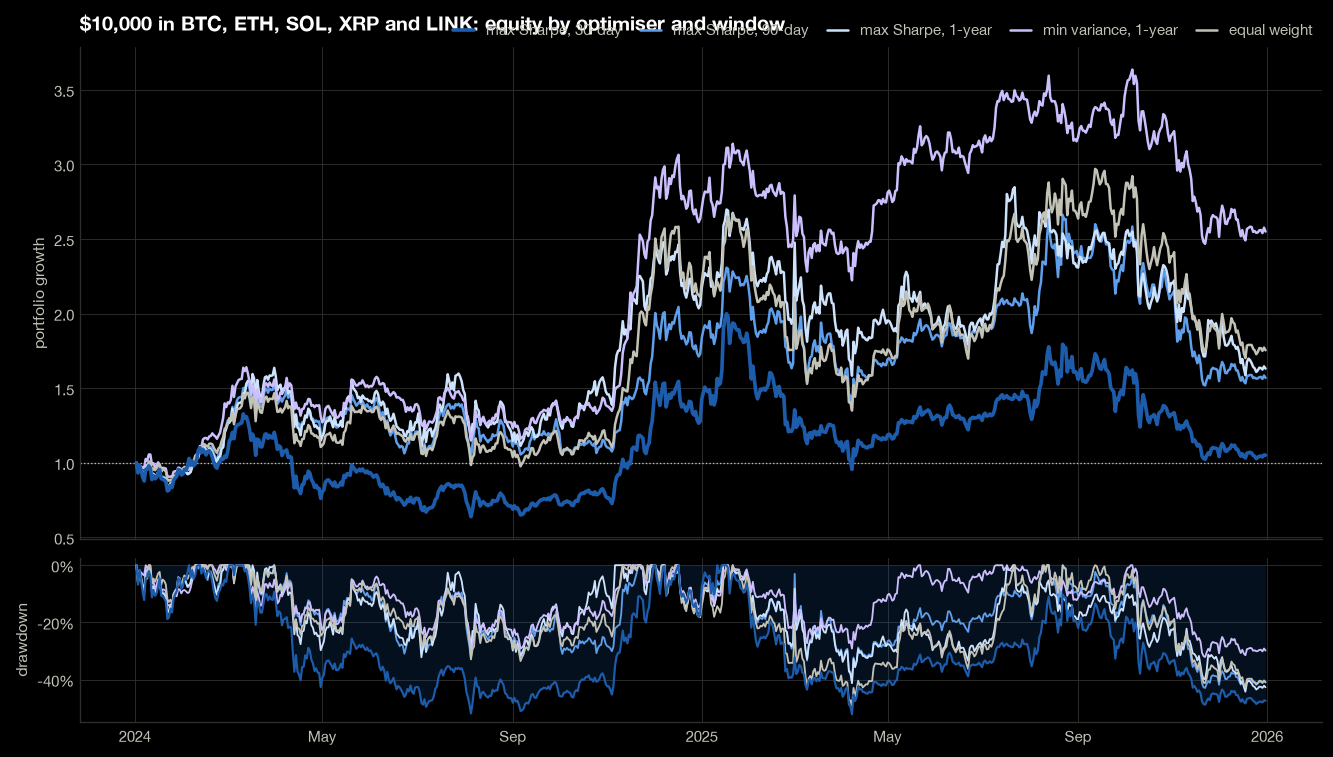

In [11]:
SHOW = {**{f"max Sharpe, {lab}": c for lab, c in zip(LOOKBACKS, LB_COLORS)},
        "min variance, 1-year": MV_COLOR, "equal weight": EW_COLOR}
plots.equity_drawdown({k: runs[k]["equity"].iloc[WARMUP:] for k in SHOW},
                      f"${INITIAL:,.0f} in BTC, ETH, SOL, XRP and LINK: equity by "
                      "optimiser and window", colors=list(SHOW.values()),
                      dd_for="max Sharpe, 30-day")
plt.show()

## Window and rebalance settings

Maximum Sharpe for more window lengths and three rebalance periods. Every cell starts on
the same day as the table above, so they are comparable with it and with each other.

equal weight, same days: return +75%, Sharpe 0.76, max drawdown -49%, fees $103


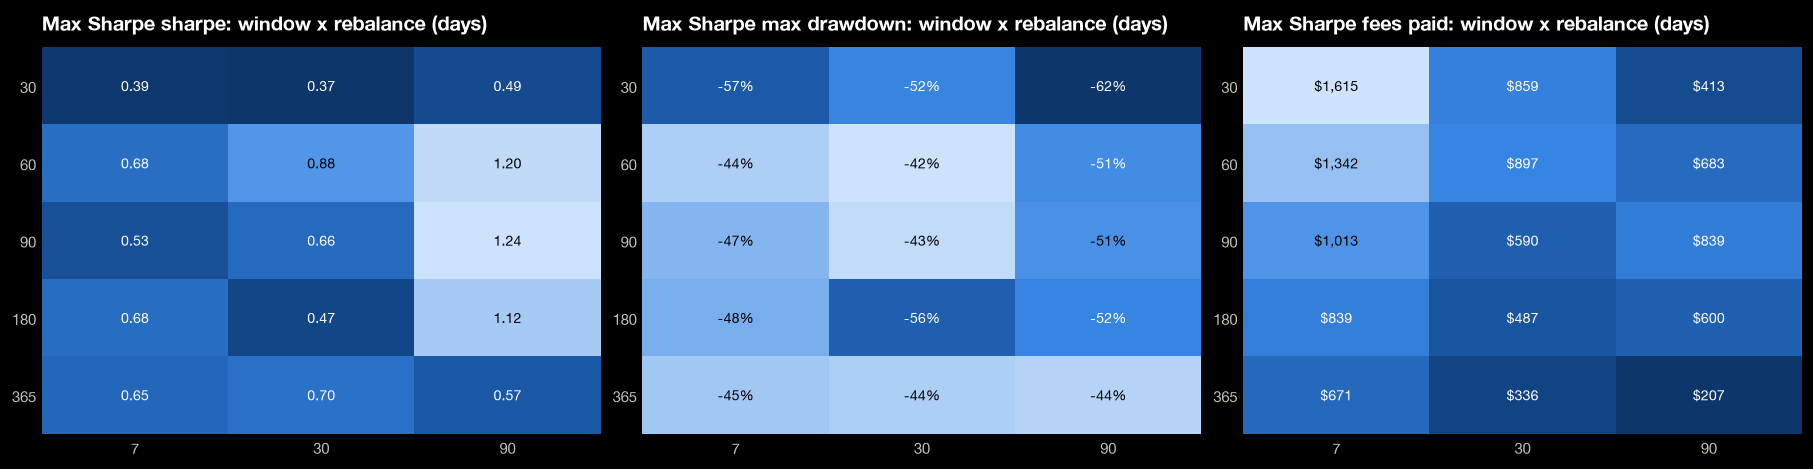

In [12]:
LB_GRID = [30, 60, 90, 180, 365]
PERIODS = [7, 30, 90]

ms_by_lb = {lb: rolling(close, lb) for lb in LB_GRID}
cells = []
for lb in LB_GRID:
    for p in PERIODS:
        cfg = PortfolioConfig(check_bars=p, band=0.0, band_all=True, min_trade_frac=0.0)
        res = run(ms_by_lb[lb], cfg)
        s = bt.stats_from_result(res, "", WARMUP, ANN)
        cells.append({"window": lb, "period": p, "fees": res["fees"],
                      **{m: s[m] for m in ("total_ret", "sharpe", "vol", "max_dd")}})
grid = pd.DataFrame(cells)
e = table.loc["equal weight"]
print(f"equal weight, same days: return {e.total_ret:+.0%}, Sharpe {e.sharpe:.2f}, "
      f"max drawdown {e.max_dd:.0%}, fees ${e['fees_$']:,.0f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8), layout="constrained")
for ax, (m, fmt, title) in zip(axes, [("sharpe", "{:.2f}", "Sharpe"),
                                      ("max_dd", "{:.0%}", "Max drawdown"),
                                      ("fees", "${:,.0f}", "Fees paid")]):
    plots.heatmap(grid.pivot(index="window", columns="period", values=m),
                  f"Max Sharpe {title.lower()}: window x rebalance (days)", fmt=fmt, ax=ax)
plt.show()

## Other baskets

The five assets above are one choice. Here the basket is drawn at random, 100 times,
five coins at a time from every coin in the file with a price on every day of the same
period. The optimiser and backtest are run on each, for each
window, and equal weight on the same basket is the benchmark.

In [13]:
N_BASKETS, SEED = 100, 0

universe = data.load_universe(path=DATA, fmt="ohlcv")
every = data.daily_panel(universe, raw=data.load_bars("1d", path=DATA, fmt="ohlcv")).close
every = every.reindex(close.index)                     # the same days as above
pool = sorted(every.columns[every.notna().all()])
rng = np.random.default_rng(SEED)
baskets = [sorted(rng.choice(pool, 5, replace=False)) for _ in range(N_BASKETS)]
print(f"{len(pool)} coins with a full history: {', '.join(pool)}")

rows = []
for coins in baskets:
    px = every[coins]
    ew = bt.stats_from_result(run(pd.DataFrame(0.2, index=px.index, columns=coins), REBAL, px),
                              "", WARMUP, ANN)
    for lab, lb in LOOKBACKS.items():
        w = rolling(px, lb).loc[span]
        top = w.idxmax(axis=1)
        s = bt.stats_from_result(run(rolling(px, lb), REBAL, px), "", WARMUP, ANN)
        rows.append({"basket": "/".join(coins), "window": lab,
                     "daily_change": (w.diff().abs().sum(axis=1) / 2).iloc[1:].mean(),
                     "top_switches": int((top != top.shift()).iloc[1:].sum()),
                     "sharpe": s["sharpe"], "max_dd": s["max_dd"],
                     "ew_sharpe": ew["sharpe"], "ew_max_dd": ew["max_dd"]})
multi = pd.DataFrame(rows)
multi["beats_ew"] = multi.sharpe > multi.ew_sharpe
med = multi.groupby("window", sort=False)[["daily_change", "top_switches", "sharpe",
                                           "ew_sharpe", "max_dd", "ew_max_dd"]].median()
med["beats_ew"] = multi.groupby("window", sort=False).beats_ew.mean()
print(f"median over {N_BASKETS} random baskets; beats_ew is the share of baskets where "
      "max Sharpe had the higher Sharpe ratio")
bt.fmt_table(med, {"daily_change": "{:.1%}", "top_switches": "{:.0f}", "sharpe": "{:.2f}",
                   "ew_sharpe": "{:.2f}", "max_dd": "{:.0%}", "ew_max_dd": "{:.0%}",
                   "beats_ew": "{:.0%}"})

24 coins with a full history: aave, ada, algo, atom, avax, bch, btc, doge, dot, etc, eth, icp, link, ltc, near, qnt, shib, sol, trx, uni, xlm, xmr, xrp, zec
median over 100 random baskets; beats_ew is the share of baskets where max Sharpe had the higher Sharpe ratio


,daily_change,top_switches,sharpe,ew_sharpe,max_dd,ew_max_dd,beats_ew
window,,,,,,,
30-day,15.1%,114,0.40,0.43,-63%,-59%,39%
90-day,7.1%,57,0.31,0.43,-64%,-59%,25%
1-year,3.1%,21,0.58,0.43,-58%,-59%,50%


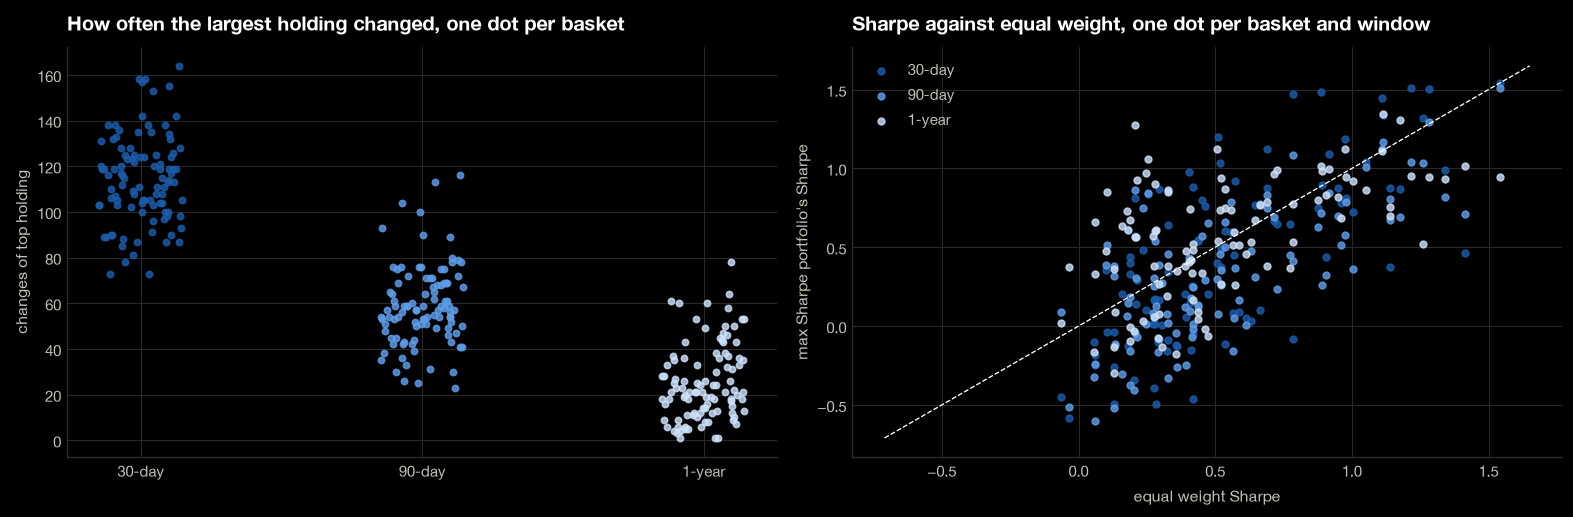

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), layout="constrained")
jitter = np.random.default_rng(1).uniform(-0.15, 0.15, N_BASKETS)
for j, (lab, col) in enumerate(zip(LOOKBACKS, LB_COLORS)):
    sub = multi[multi.window == lab]
    axes[0].scatter(j + jitter, sub.top_switches, s=14, color=col, alpha=0.8)
    axes[1].scatter(sub.ew_sharpe, sub.sharpe, s=16, color=col, alpha=0.8, label=lab)
axes[0].set_xticks(range(len(LOOKBACKS)), list(LOOKBACKS))
axes[0].set_ylabel("changes of top holding")
axes[0].set_title("How often the largest holding changed, one dot per basket")
lo = min(axes[1].get_xlim()[0], axes[1].get_ylim()[0])
hi = max(axes[1].get_xlim()[1], axes[1].get_ylim()[1])
axes[1].plot([lo, hi], [lo, hi], color=plt.rcParams["text.color"], lw=0.8, ls="--")
axes[1].set_xlabel("equal weight Sharpe")
axes[1].set_ylabel("max Sharpe portfolio's Sharpe")
axes[1].set_title("Sharpe against equal weight, one dot per basket and window")
axes[1].legend(loc="upper left")
plt.show()

Reading the results: TODO

## Video: the inputs won't sit still

Two parts, joined. First, each asset's return distribution as the optimiser sees it, a
bell curve centred on the window's mean and as wide as its volatility, re-estimated day
by day for each window, with the maximum-Sharpe weights it picks above each panel. Then
the three maximum-Sharpe backtests racing equal weight, with drawdowns and fees paid
underneath.

In [17]:
import os
import tempfile
from pathlib import Path

from IPython.display import Video

from algo_trading.backtest import animate

BRAND = PROJECT_ROOT.parent / "public"   # local brand assets; not part of this repo
FONT = BRAND / "fonts" / "alliance-no1" / "Degarism Studio - Alliance No.1 Light.otf"
ICON = BRAND / "hpt-icon-purple.png"
font = FONT if FONT.exists() else None
icon = ICON if ICON.exists() else None

AUDIO = PROJECT_ROOT / ".audio" / "UNRELEASED Söltö & Hugel – Jamaican (Bam Bam) - Kiril Trendafilov (192k).mp3"
AUDIO_START = 41.9           # seconds into the track to start from

# What the optimiser sees of each asset on each day: its window's mean and volatility.
means, vols, wts = {}, {}, {}
for lab, lb in LOOKBACKS.items():
    est = [estimates(close, close.index.get_loc(d), lb) for d in span]
    key = f"{lab} window"
    means[key] = pd.DataFrame([mu for mu, _ in est], index=span, columns=TOKENS)
    vols[key] = pd.DataFrame([np.sqrt(np.diag(cov)) for _, cov in est], index=span,
                             columns=TOKENS)
    wts[key] = targets[("max sharpe", lab)].loc[span]
means, vols, wts = ({k: v.rename(columns=NAMES) for k, v in d.items()}
                    for d in (means, vols, wts))

race = {**{lab: runs[f"max Sharpe, {lab}"] for lab in LOOKBACKS},
        "equal weight": runs["equal weight"]}
fees_paid = {k: res["fills"].groupby("ts").fee.sum().reindex(span, fill_value=0).cumsum()
             for k, res in race.items()}        # cumulative, in dollars
st = stability.loc["max sharpe"]
short, long_ = list(LOOKBACKS)[0], list(LOOKBACKS)[-1]
t_s, t_e = table.loc[f"max Sharpe, {short}"], table.loc["equal weight"]

with tempfile.TemporaryDirectory() as tmp:
    bells = animate.bell_morph(
        means, vols, wts, Path(tmp) / "bells.mp4", title="Same assets, different history",
        subtitle="each asset as the optimiser sees it: mean ± volatility, daily",
        caption=f"{short} window: top holding changed {st.loc[short, 'top_switches']:.0f} times. "
                f"{long_}: {st.loc[long_, 'top_switches']:.0f}.",
        colors=ASSET_COLORS, seconds=16, font=font, icon=icon, progress=False)
    racing = animate.equity_race(
        {k: res["equity"].loc[span] for k, res in race.items()}, Path(tmp) / "race.mp4",
        title="Does chasing the frontier pay?",
        subtitle=f"${INITIAL:,.0f} · 5 assets · max Sharpe, monthly · {FEE / 100:g}% fee",
        caption=f"{short}: {t_s.total_ret:+.0%}, ${t_s['fees_$']:,.0f} fees. "
                f"Equal weight: {t_e.total_ret:+.0%}.",
        log=False, colors=[*plots.ramp(len(LOOKBACKS), hue="purple"), plots.color(1)],
        widths={"equal weight": 1.1}, dd_for=short, seconds=16, fees=fees_paid,
        drawdown=True, font=font, icon=icon, progress=False)
    video = animate.concat([bells, racing], PROJECT_ROOT / ".media" / "mean_var_opt.mp4",
                           audio=AUDIO if AUDIO.exists() else None, audio_start=AUDIO_START)

Video(os.path.relpath(video), embed=False, width=540)